In [6]:
!pip install lime shap catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import lime
import lime.lime_tabular
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from google.colab import drive

In [8]:
# 1. Connect to Drive and Load Data
drive.mount('/content/drive')
df_clean = pd.read_csv('/content/drive/MyDrive/cardiovascular_ready_for_models.csv')

# 2. DEFINE X AND y (This was missing from your code!)
# Look at the columns in df_clean to find the exact name of your target.
# Based on your EDA notebook, we assume it's the last column or named 'CARDIO_DISEASE'.
if 'CARDIO_DISEASE' in df_clean.columns:
    target_col = 'CARDIO_DISEASE'
elif 'target' in df_clean.columns:
    target_col = 'target'
else:
    target_col = df_clean.columns[-1] # Fallback to the last column

X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing complete. Target column identified as:", target_col)
print("✅ Number of features for modeling:", X_train_scaled.shape[1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Preprocessing complete. Target column identified as: CARDIO_DISEASE
✅ Number of features for modeling: 11


In [22]:
# 1. Initialize SVM
svm_model = SVC(
    kernel='rbf',
    probability=True,
    C=1.0,
    random_state=42
)

# 2. Train
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [23]:
# 3. Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM Model Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

--- SVM Model Results ---
Accuracy: 0.7366
AUC Score: 0.7958


  0%|          | 0/10 [00:00<?, ?it/s]

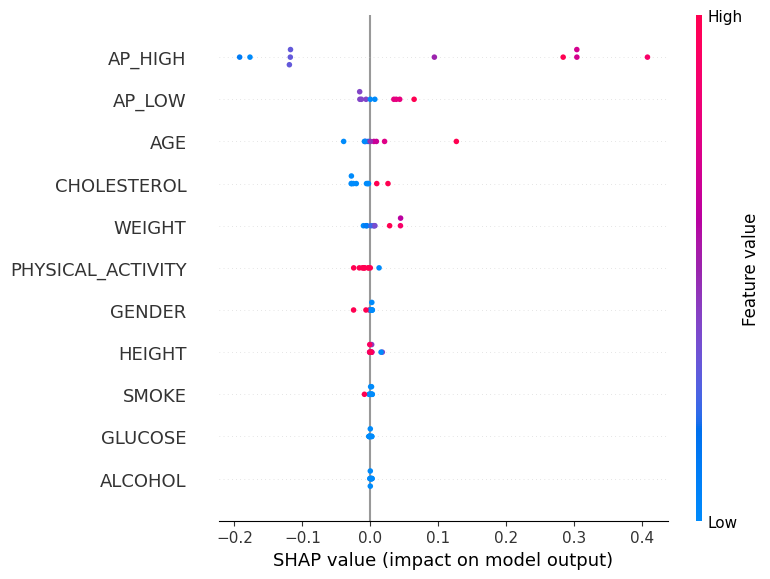

In [25]:
#  XAI TECHNIQUES
# Technique 1: SHAP
background_summary = shap.kmeans(X_train_scaled, 10)
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, background_summary)
shap_values_svm_raw = explainer_svm.shap_values(X_test_scaled[:10])
if isinstance(shap_values_svm_raw, list):
    shap_values_array = np.array(shap_values_svm_raw[1])
else:
    shap_values_array = shap_values_svm_raw[:, :, 1]

shap.summary_plot(shap_values_array, X_test_scaled[:10], feature_names=X.columns)

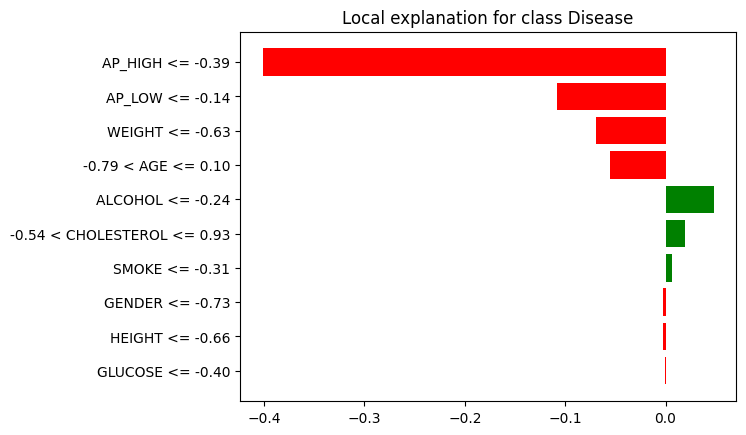

In [26]:
# Technique 2: LIME
lime_svm = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
lime_svm.explain_instance(X_test_scaled[0], svm_model.predict_proba).as_pyplot_figure()
plt.show()

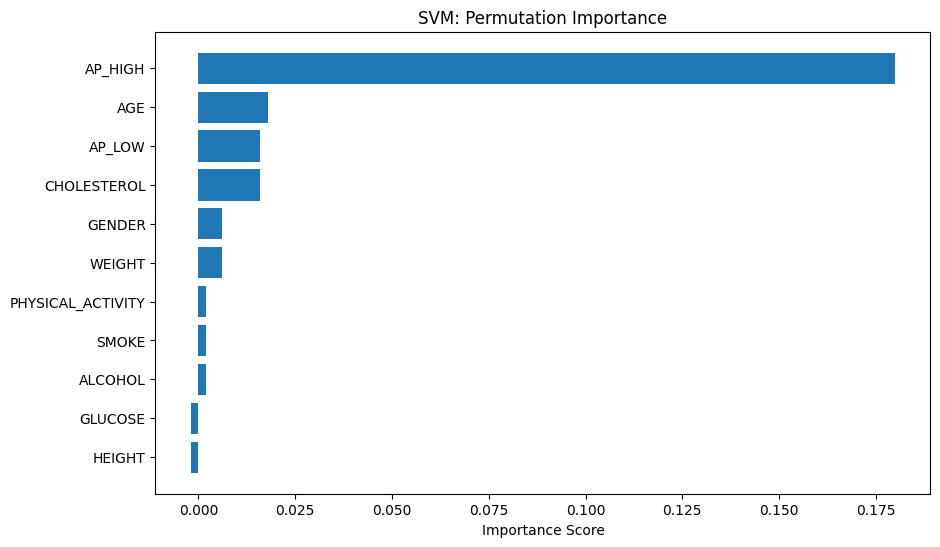

In [34]:
# Technique 3: Permutation Importance
sample_size = min(100, len(X_test_scaled))
X_test_subset = X_test_scaled[:sample_size]
y_test_subset = y_test[:sample_size]

# THE FIX: Added n_jobs=-1 to run in parallel
result_svm = permutation_importance(
    svm_model,
    X_test_subset,
    y_test_subset,
    n_repeats=5,
    random_state=42,
    n_jobs=-1 # <-- This tells it to use all CPU cores
)

# Plotting the results
sorted_idx_svm = result_svm.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx_svm], result_svm.importances_mean[sorted_idx_svm])
plt.title("SVM: Permutation Importance")
plt.xlabel("Importance Score")
plt.show()

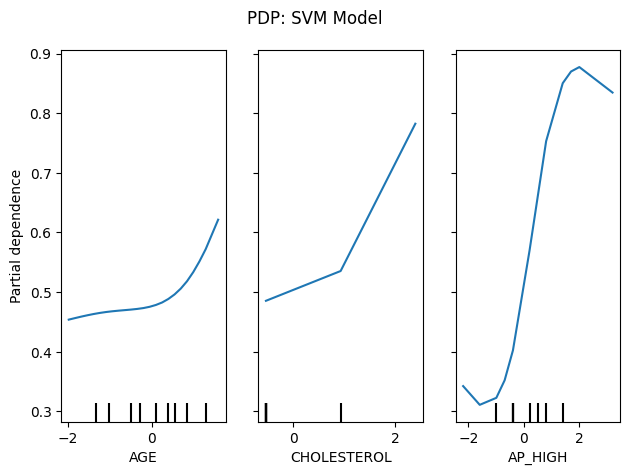

In [35]:
# Technique 4: Partial Dependence Plots (PDP)
sample_size_pdp = min(100, len(X_train_scaled))
X_train_subset = X_train_scaled[:sample_size_pdp]

features_to_plot = [col for col in ['AGE', 'CHOLESTEROL', 'AP_HIGH'] if col in X.columns]
if not features_to_plot:
    features_to_plot = [0, 1, 2]

PartialDependenceDisplay.from_estimator(
    svm_model,
    X_train_subset, # <-- Using the smaller subset here
    features_to_plot,
    feature_names=X.columns.tolist(),
    target=1,
    grid_resolution=30,  # <-- Calculates 30 points per graph instead of 100
    n_jobs=-1            # <-- Uses all CPU cores
)

plt.suptitle("PDP: SVM Model")
plt.tight_layout()
plt.show()